In [51]:
# =========================
# Fashion-MNIST Demo (Colab)
# =========================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [52]:
# 1) Load dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

class_names = [
    "Zero", "One", "Two", "Three", "Four",
    "Five", "Six", "Seven", "Eight", "Nine"
]

print("Training set:", x_train.shape, y_train.shape)
print("Test set:", x_test.shape, y_test.shape)

Training set: (60000, 28, 28) (60000,)
Test set: (10000, 28, 28) (10000,)


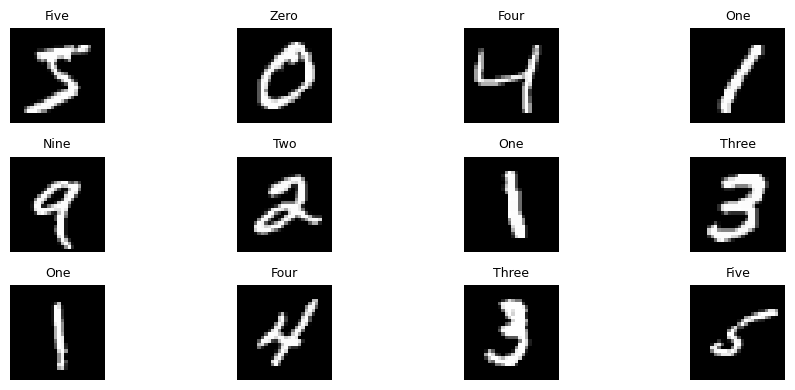

In [53]:
# 2) Visualize a few samples
plt.figure(figsize=(10,4))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [54]:
# 3) Preprocess: normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

In [55]:
# 4) Build a simple model (baseline)
#    Flatten 28x28 -> vector, then dense layers -> 10-class softmax
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# 5) Train
history = model.fit(
    x_train, y_train,
    epochs=8,
    validation_split=0.2,
    batch_size=64,
    verbose=1
)

Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9076 - loss: 0.3278 - val_accuracy: 0.9478 - val_loss: 0.1858
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9562 - loss: 0.1521 - val_accuracy: 0.9626 - val_loss: 0.1268
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9697 - loss: 0.1062 - val_accuracy: 0.9688 - val_loss: 0.1095
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9769 - loss: 0.0808 - val_accuracy: 0.9703 - val_loss: 0.0996
Epoch 5/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9804 - loss: 0.0645 - val_accuracy: 0.9719 - val_loss: 0.0955
Epoch 6/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9851 - loss: 0.0519 - val_accuracy: 0.9727 - val_loss: 0.0915
Epoch 7/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9883 - loss: 0.0407 - val_accuracy: 0.9744 - val_loss: 0.0890
Epoch 8/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9903 - loss: 0.0334 - val_accuracy: 0.9753 - v

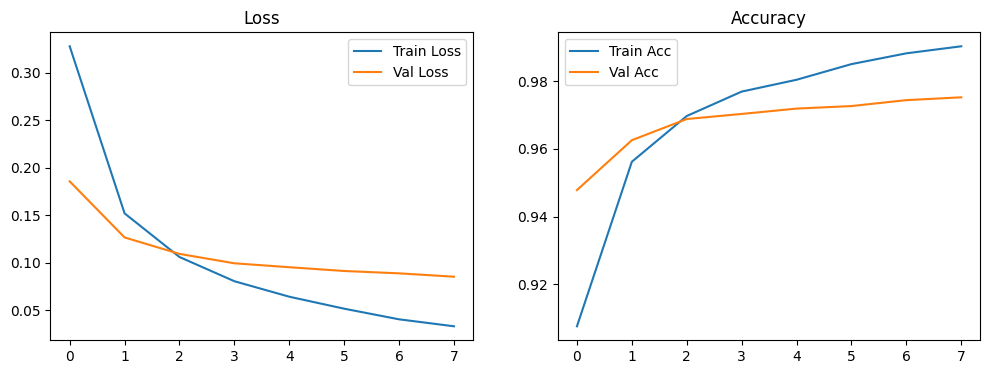

In [57]:
# 6) Plot training curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.show()

In [58]:
# 7) Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9751


In [59]:
# 8) Make predictions on test set
pred_probs = model.predict(x_test, verbose=0)     # probabilities
pred_labels = np.argmax(pred_probs, axis=1)       # chosen class index

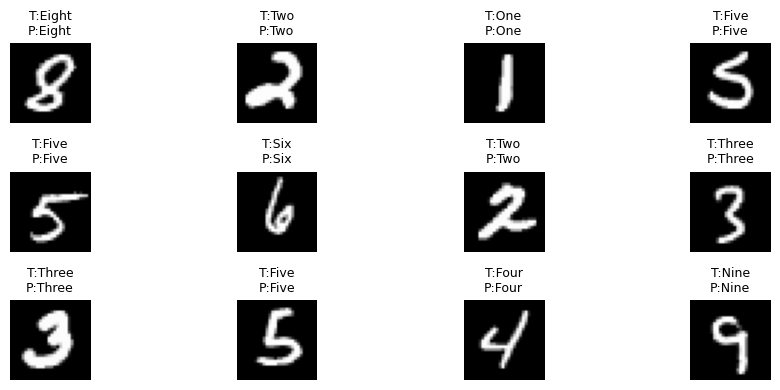

In [60]:
# 9) Show a few predictions (correct vs wrong)
def show_predictions(n=12):
    plt.figure(figsize=(10,4))
    idxs = np.random.choice(len(x_test), n, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(3,4,i+1)
        plt.imshow(x_test[idx], cmap="gray")
        true_name = class_names[y_test[idx]]
        pred_name = class_names[pred_labels[idx]]
        title = f"T:{true_name}\nP:{pred_name}"
        plt.title(title, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(12)


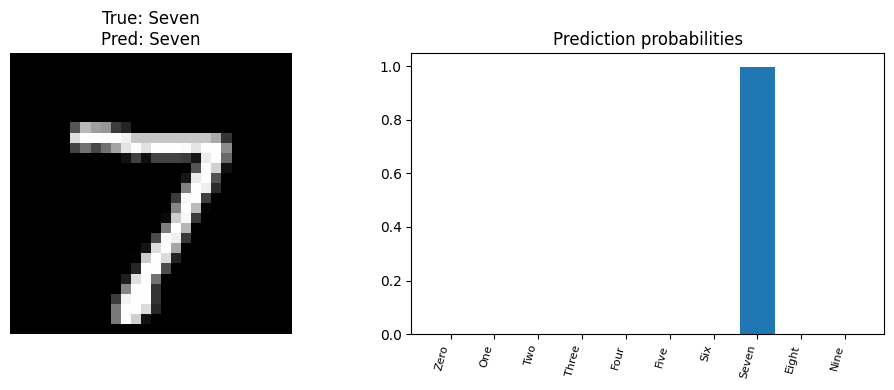

In [61]:
# 10) One-image "explainable" view: image + probability bar chart
def predict_one(index):
    img = x_test[index]
    true = y_test[index]
    probs = model.predict(img[np.newaxis, ...], verbose=0)[0]
    pred = np.argmax(probs)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.bar(range(10), probs)
    plt.xticks(range(10), class_names, rotation=75, ha="right", fontsize=8)
    plt.title("Prediction probabilities")
    plt.tight_layout()
    plt.show()

predict_one(0)